# Seoul Bike Sharing Demand - Data Preprocessing & EDA

Notebook này thực hiện toàn bộ quy trình đọc dữ liệu, kiểm tra chất lượng, tiền xử lý, tạo đặc trưng và khám phá nhu cầu thuê xe đạp tại Seoul. Phân tích chỉ mô tả các mối liên hệ quan sát được; không xây dựng mô hình dự đoán và không diễn giải tương quan thành quan hệ nhân quả.

## 1. Import Libraries

Nạp các thư viện xử lý dữ liệu và trực quan hóa. `RANDOM_STATE` được cố định để các biểu đồ có sampling có thể tái lập.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RANDOM_STATE = 42
SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
TIME_ORDER = ["Night", "Morning", "Afternoon", "Evening"]
SEASON_COLORS = {
    "Winter": "#4C78A8", "Spring": "#59A14F",
    "Summer": "#F28E2B", "Autumn": "#B07AA1",
}

## 2. Load Dataset

Dữ liệu được đọc từ đường dẫn tương đối `data/SeoulBikeData.csv`. Hàm bên dưới thử lần lượt UTF-8, CP949 và Latin-1 để xử lý khác biệt encoding của bộ dữ liệu gốc.

In [2]:
DATA_PATH = Path("data/SeoulBikeData.csv")

def read_csv_with_fallback(path, encodings=("utf-8", "cp949", "latin1")):
    last_error = None
    for encoding in encodings:
        try:
            frame = pd.read_csv(path, encoding=encoding)
            print(f"Loaded with encoding: {encoding}")
            return frame
        except UnicodeDecodeError as error:
            last_error = error
    raise UnicodeDecodeError(
        last_error.encoding, last_error.object, last_error.start,
        last_error.end, "All configured encodings failed"
    )

df = read_csv_with_fallback(DATA_PATH)
display(df.head())

Loaded with encoding: cp949


,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 3. Data Understanding

Kiểm tra kích thước, schema, kiểu dữ liệu và thống kê mô tả trước khi thay đổi dữ liệu.

In [3]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumns:")
display(pd.DataFrame({"Column": df.columns}))

Shape: 8,760 rows × 14 columns

Columns:


,Column
0,Date
1,Rented Bike Count
2,Hour
3,Temperature(캜)
4,Humidity(%)
5,Wind speed (m/s)
6,Visibility (10m)
7,Dew point temperature(캜)
8,Solar Radiation (MJ/m2)
9,Rainfall(mm)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [5]:
display(df.describe().T)
non_numeric_columns = df.select_dtypes(exclude="number").columns
display(df[non_numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(캜),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(캜),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


,count,unique,top,freq
Date,8760,365,01/12/2017,24
Seasons,8760,4,Spring,2208
Holiday,8760,2,No Holiday,8328
Functioning Day,8760,2,Yes,8465


## 4. Data Cleaning & Preprocessing

Chuẩn hóa tên cột, kiểm tra missing/duplicate, chuyển kiểu dữ liệu, xác thực miền giá trị và thống kê outlier bằng quy tắc IQR. Các giá trị lớn hợp lệ không bị tự động xóa.

In [6]:
column_mapping = {
    "Date": "Date",
    "Rented Bike Count": "Rented_Bike_Count",
    "Hour": "Hour",
    "Temperature(°C)": "Temperature",
    "Humidity(%)": "Humidity",
    "Wind speed (m/s)": "Wind_Speed",
    "Visibility (10m)": "Visibility",
    "Dew point temperature(°C)": "Dew_Point_Temperature",
    "Solar Radiation (MJ/m2)": "Solar_Radiation",
    "Rainfall(mm)": "Rainfall",
    "Snowfall (cm)": "Snowfall",
    "Seasons": "Seasons",
    "Holiday": "Holiday",
    "Functioning Day": "Functioning_Day",
}

# The CP949 file can contain a malformed degree symbol in some distributions,
# so position-based fallback keeps the expected schema explicit and robust.
expected_names = list(column_mapping.values())
renamed_columns = [column_mapping.get(column, expected_names[index])
                   for index, column in enumerate(df.columns)]
df.columns = renamed_columns
display(pd.DataFrame({"Standardized_Column": df.columns}))

,Standardized_Column
0,Date
1,Rented_Bike_Count
2,Hour
3,Temperature
4,Humidity
5,Wind_Speed
6,Visibility
7,Dew_Point_Temperature
8,Solar_Radiation
9,Rainfall


In [7]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": df.isna().mean().mul(100).round(2),
})
display(missing_summary)
print(f"Total missing values: {int(missing_summary['Missing_Count'].sum())}")

,Missing_Count,Missing_Percent
Date,0,0.0
Rented_Bike_Count,0,0.0
Hour,0,0.0
Temperature,0,0.0
Humidity,0,0.0
Wind_Speed,0,0.0
Visibility,0,0.0
Dew_Point_Temperature,0,0.0
Solar_Radiation,0,0.0
Rainfall,0,0.0


Total missing values: 0


**Nhận xét:** Dữ liệu không có giá trị thiếu, vì vậy không cần áp dụng imputing. Việc giữ nguyên các quan sát giúp tránh đưa thêm giả định không cần thiết vào dữ liệu.

In [8]:
rows_before = len(df)
duplicate_count = int(df.duplicated().sum())
if duplicate_count:
    df = df.drop_duplicates().copy()
rows_after = len(df)

print(f"Fully duplicated rows: {duplicate_count:,}")
print(f"Rows before: {rows_before:,} | Rows after: {rows_after:,}")

Fully duplicated rows: 0
Rows before: 8,760 | Rows after: 8,760


In [9]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="raise")
df["Seasons"] = pd.Categorical(df["Seasons"], categories=SEASON_ORDER, ordered=True)
df["Holiday"] = pd.Categorical(
    df["Holiday"], categories=["No Holiday", "Holiday"], ordered=True
)
df["Functioning_Day"] = pd.Categorical(
    df["Functioning_Day"], categories=["No", "Yes"], ordered=True
)

display(df.dtypes.to_frame("Data_Type"))
print(f"Date range: {df['Date'].min():%d/%m/%Y} to {df['Date'].max():%d/%m/%Y}")

,Data_Type
Date,datetime64[us]
Rented_Bike_Count,int64
Hour,int64
Temperature,float64
Humidity,int64
Wind_Speed,float64
Visibility,int64
Dew_Point_Temperature,float64
Solar_Radiation,float64
Rainfall,float64


Date range: 01/12/2017 to 30/11/2018


In [10]:
invalid_checks = {
    "Hour outside 0-23": ~df["Hour"].between(0, 23),
    "Humidity outside 0-100": ~df["Humidity"].between(0, 100),
    "Negative bike count": df["Rented_Bike_Count"] < 0,
    "Negative rainfall": df["Rainfall"] < 0,
    "Negative snowfall": df["Snowfall"] < 0,
    "Negative wind speed": df["Wind_Speed"] < 0,
    "Negative visibility": df["Visibility"] < 0,
}
invalid_summary = pd.Series(
    {label: int(mask.sum()) for label, mask in invalid_checks.items()},
    name="Invalid_Count",
).to_frame()
display(invalid_summary)

,Invalid_Count
Hour outside 0-23,0
Humidity outside 0-100,0
Negative bike count,0
Negative rainfall,0
Negative snowfall,0
Negative wind speed,0
Negative visibility,0


In [11]:
outlier_columns = [
    "Rented_Bike_Count", "Temperature", "Humidity",
    "Wind_Speed", "Rainfall", "Snowfall",
]

def iqr_outlier_summary(frame, columns):
    records = []
    for column in columns:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (frame[column] < lower) | (frame[column] > upper)
        records.append({
            "Variable": column, "Q1": q1, "Q3": q3, "IQR": iqr,
            "Lower_Bound": lower, "Upper_Bound": upper,
            "Outlier_Count": int(mask.sum()),
            "Outlier_Percent": round(mask.mean() * 100, 2),
        })
    return pd.DataFrame(records).set_index("Variable")

outlier_summary = iqr_outlier_summary(df, outlier_columns)
display(outlier_summary.round(2))

,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
Variable,,,,,,,
Rented_Bike_Count,191.0,1065.25,874.25,-1120.38,2376.62,158,1.80
Temperature,3.5,22.50,19.00,-25.00,51.00,0,0.00
Humidity,42.0,74.00,32.00,-6.00,122.00,0,0.00
Wind_Speed,0.9,2.30,1.40,-1.20,4.40,161,1.84
Rainfall,0.0,0.00,0.00,0.00,0.00,528,6.03
Snowfall,0.0,0.00,0.00,0.00,0.00,443,5.06


**Quyết định xử lý outlier:** IQR được dùng để phát hiện và thống kê, không phải để mặc định kết luận dữ liệu sai. Các giá trị thuê xe cao, mưa và tuyết lớn có thể là sự kiện thời tiết hoặc nhu cầu thực; vì vậy toàn bộ được giữ lại. Phân phối và các điểm cực trị sẽ được quan sát tiếp ở histogram, box plot, violin plot và các biểu đồ mật độ.

## 5. Feature Engineering

Tạo các đặc trưng lịch, thời điểm trong ngày, giờ cao điểm, mức demand theo phân vị và chênh lệch nhiệt độ–điểm sương.

In [12]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = pd.Categorical(
    df["Date"].dt.month_name(),
    categories=list(pd.date_range("2024-01-01", periods=12, freq="MS").month_name()),
    ordered=True,
)
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Day_Name"] = pd.Categorical(
    df["Date"].dt.day_name(), categories=DAY_ORDER, ordered=True
)
df["Is_Weekend"] = df["DayOfWeek"].ge(5)
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df["TimeOfDay"] = pd.cut(
    df["Hour"], bins=[-1, 5, 11, 17, 23], labels=TIME_ORDER, ordered=True
)
df["Rush_Hour"] = df["Hour"].isin([7, 8, 9, 17, 18, 19])

try:
    df["Demand_Level"] = pd.qcut(
        df["Rented_Bike_Count"], q=3, labels=["Low", "Medium", "High"]
    )
except ValueError:
    # Ranking only resolves duplicate quantile edges; original demand values stay unchanged.
    df["Demand_Level"] = pd.qcut(
        df["Rented_Bike_Count"].rank(method="first"),
        q=3, labels=["Low", "Medium", "High"],
    )

df["Temperature_DewPoint_Diff"] = (
    df["Temperature"] - df["Dew_Point_Temperature"]
)

In [13]:
engineered_features = [
    "Year", "Month", "Month_Name", "Day", "DayOfWeek", "Day_Name",
    "Is_Weekend", "WeekOfYear", "TimeOfDay", "Rush_Hour",
    "Demand_Level", "Temperature_DewPoint_Diff",
]
display(df[["Date", "Hour", "Rented_Bike_Count"] + engineered_features].head())
display(df[engineered_features].dtypes.to_frame("Data_Type"))

feature_summary = pd.DataFrame({
    "Feature": engineered_features,
    "Purpose": [
        "Calendar year", "Calendar month number", "Ordered month label",
        "Day of month", "Monday=0 to Sunday=6", "Ordered weekday label",
        "Weekend indicator", "ISO week number", "Four-part day period",
        "07-09 or 17-19 indicator", "Demand tercile", "Temperature minus dew point",
    ],
})
display(feature_summary)

,Date,Hour,Rented_Bike_Count,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Is_Weekend,WeekOfYear,TimeOfDay,Rush_Hour,Demand_Level,Temperature_DewPoint_Diff
0,2017-12-01,0,254,2017,12,December,1,4,Friday,False,48,Night,False,Low,12.4
1,2017-12-01,1,204,2017,12,December,1,4,Friday,False,48,Night,False,Low,12.1
2,2017-12-01,2,173,2017,12,December,1,4,Friday,False,48,Night,False,Low,11.7
3,2017-12-01,3,107,2017,12,December,1,4,Friday,False,48,Night,False,Low,11.4
4,2017-12-01,4,78,2017,12,December,1,4,Friday,False,48,Night,False,Low,12.6


,Data_Type
Year,int32
Month,int32
Month_Name,category
Day,int32
DayOfWeek,int32
Day_Name,category
Is_Weekend,bool
WeekOfYear,int64
TimeOfDay,category
Rush_Hour,bool


,Feature,Purpose
0,Year,Calendar year
1,Month,Calendar month number
2,Month_Name,Ordered month label
3,Day,Day of month
4,DayOfWeek,Monday=0 to Sunday=6
5,Day_Name,Ordered weekday label
6,Is_Weekend,Weekend indicator
7,WeekOfYear,ISO week number
8,TimeOfDay,Four-part day period
9,Rush_Hour,07-09 or 17-19 indicator


## 6. Univariate Analysis

Khám phá hình dạng phân phối của biến mục tiêu bằng histogram, KDE và ECDF. Mỗi biểu đồ là một output riêng.

### Chart 01 — Histogram: Distribution of Rented Bike Count

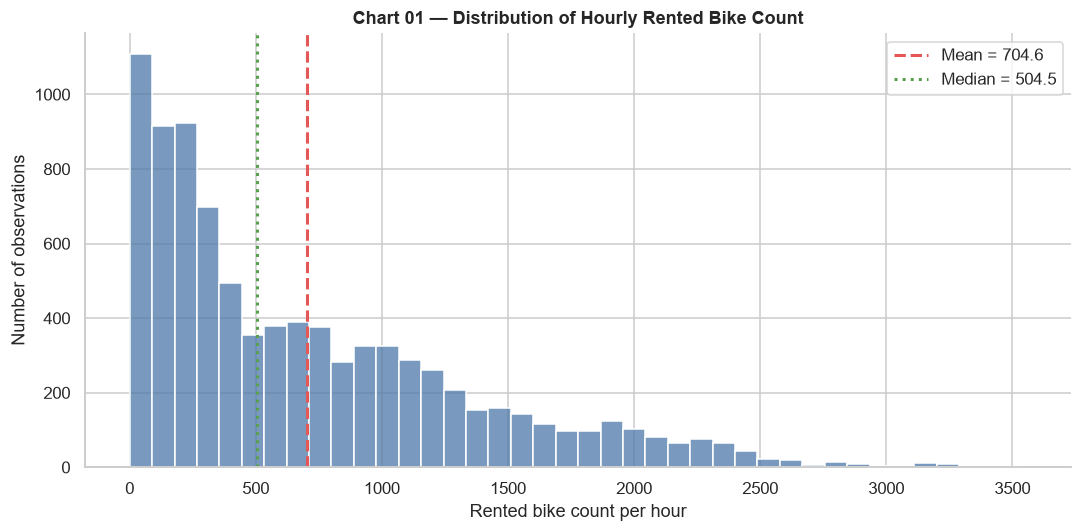

In [14]:
demand_mean = df["Rented_Bike_Count"].mean()
demand_median = df["Rented_Bike_Count"].median()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="Rented_Bike_Count", bins=40, color="#4C78A8", ax=ax)
ax.axvline(demand_mean, color="#E45756", linestyle="--", linewidth=2,
           label=f"Mean = {demand_mean:,.1f}")
ax.axvline(demand_median, color="#59A14F", linestyle=":", linewidth=2,
           label=f"Median = {demand_median:,.1f}")
ax.set(title="Chart 01 — Distribution of Hourly Rented Bike Count",
       xlabel="Rented bike count per hour", ylabel="Number of observations")
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét:** Mean (704,6) cao hơn median (504,5) và skewness khoảng 1,15, cho thấy phân phối demand theo giờ lệch phải. Phần lớn quan sát nằm ở mức thấp–trung bình, trong khi một số giờ có lượng thuê rất cao tạo đuôi phải dài.

### Chart 02 — KDE Plot: Density of Rented Bike Count

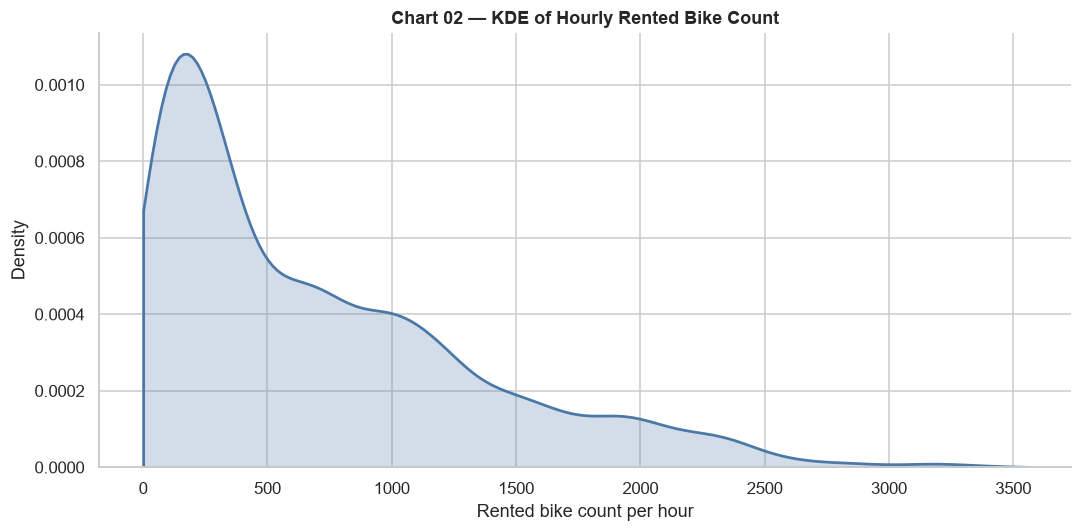

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x="Rented_Bike_Count", fill=True, color="#4C78A8",
            linewidth=1.8, cut=0, ax=ax)
ax.set(title="Chart 02 — KDE of Hourly Rented Bike Count",
       xlabel="Rented bike count per hour", ylabel="Density")
plt.tight_layout()
plt.show()

**Nhận xét:** Đường KDE xác nhận mật độ tập trung mạnh ở vùng demand thấp và giảm dần về phía các giá trị lớn. KDE là đường làm mượt nên dùng để đọc hình dạng tổng quát, không thay thế tần số chính xác của histogram.

### Chart 03 — ECDF Plot: Cumulative Distribution

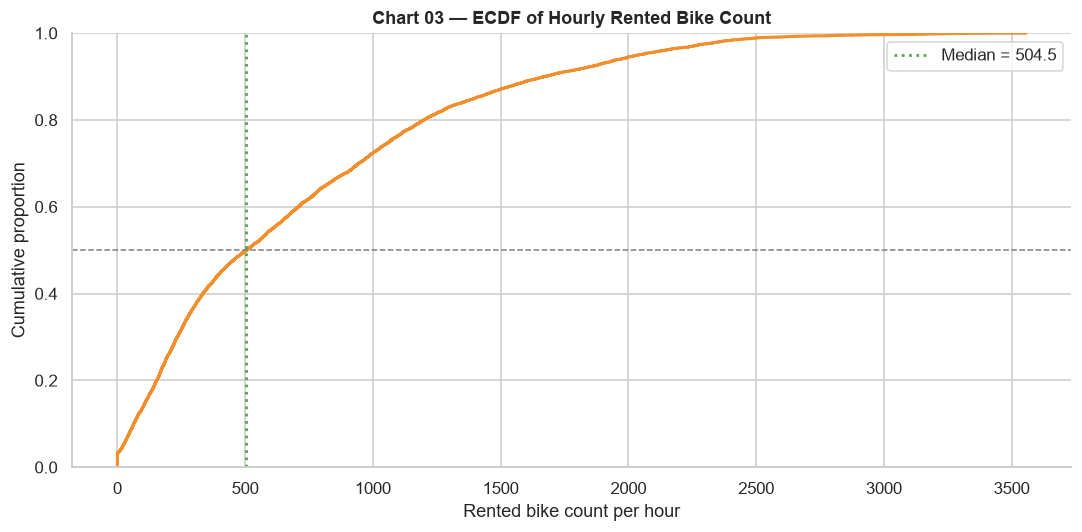

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.ecdfplot(data=df, x="Rented_Bike_Count", color="#F28E2B", linewidth=2, ax=ax)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.axvline(demand_median, color="#59A14F", linestyle=":", linewidth=1.8,
           label=f"Median = {demand_median:,.1f}")
ax.set(title="Chart 03 — ECDF of Hourly Rented Bike Count",
       xlabel="Rented bike count per hour", ylabel="Cumulative proportion")
ax.legend()
plt.tight_layout()
plt.show()

**Cách đọc ECDF:** Với một giá trị trên trục x, trục y cho biết tỷ lệ quan sát có demand nhỏ hơn hoặc bằng giá trị đó. Đường 50% cắt ECDF tại median 504,5 lượt/giờ.

## 7. Bivariate Analysis

So sánh demand giữa mùa, ngày, ngày lễ, thời điểm trong ngày và các điều kiện thời tiết. Các bảng tổng hợp quan trọng được hiển thị trước biểu đồ.

### Chart 04 — Box Plot: Demand by Season

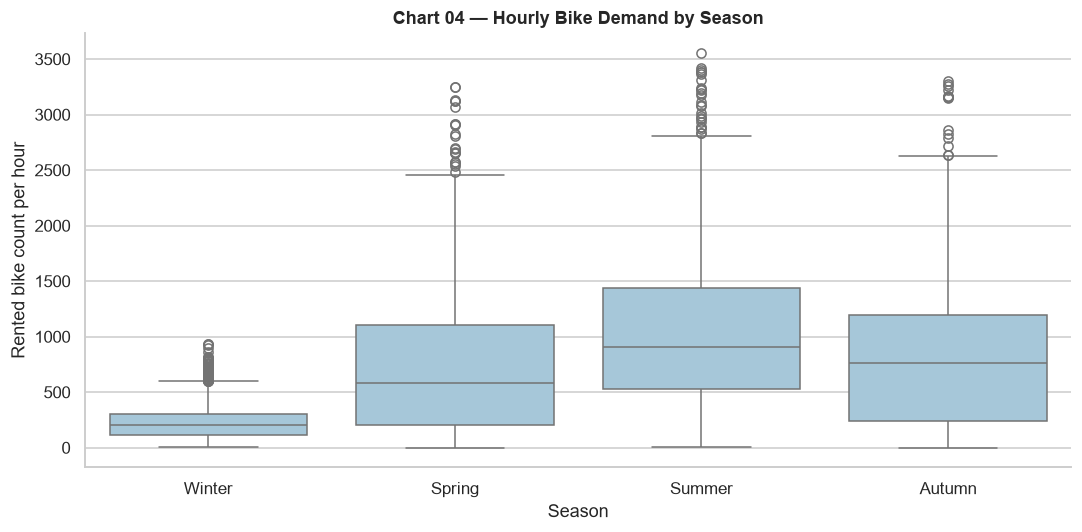

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="Seasons", y="Rented_Bike_Count", order=SEASON_ORDER,
            color="#9ECAE1", showfliers=True, ax=ax)
ax.set(title="Chart 04 — Hourly Bike Demand by Season",
       xlabel="Season", ylabel="Rented bike count per hour")
plt.tight_layout()
plt.show()

### Chart 05 — Violin Plot: Demand Distribution by Season

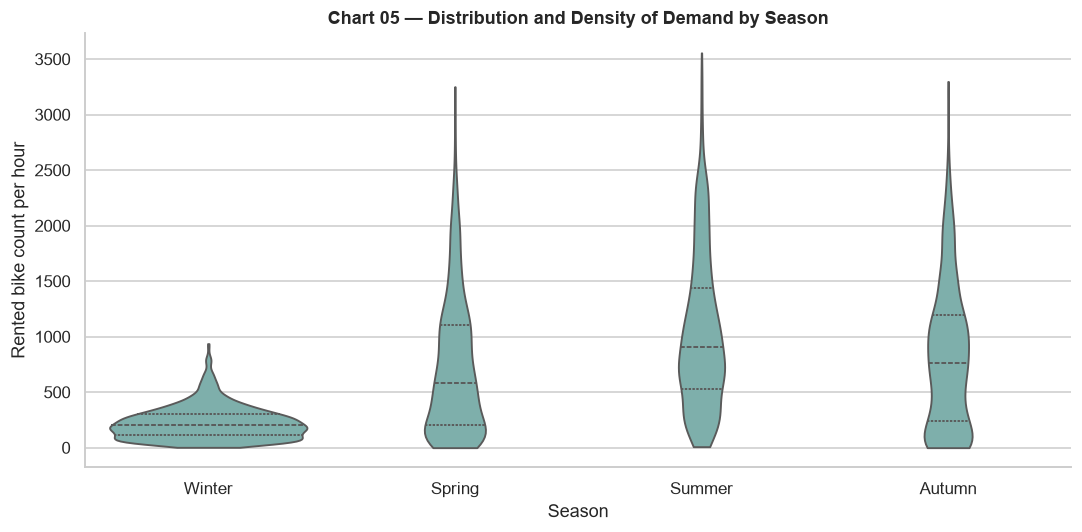

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x="Seasons", y="Rented_Bike_Count", order=SEASON_ORDER,
               color="#76B7B2", inner="quartile", cut=0, ax=ax)
ax.set(title="Chart 05 — Distribution and Density of Demand by Season",
       xlabel="Season", ylabel="Rented bike count per hour")
plt.tight_layout()
plt.show()

### Chart 06 — Bar Chart: Average Demand by Season

,Average_Demand
Seasons,
Winter,225.54
Spring,730.03
Summer,1034.07
Autumn,819.60


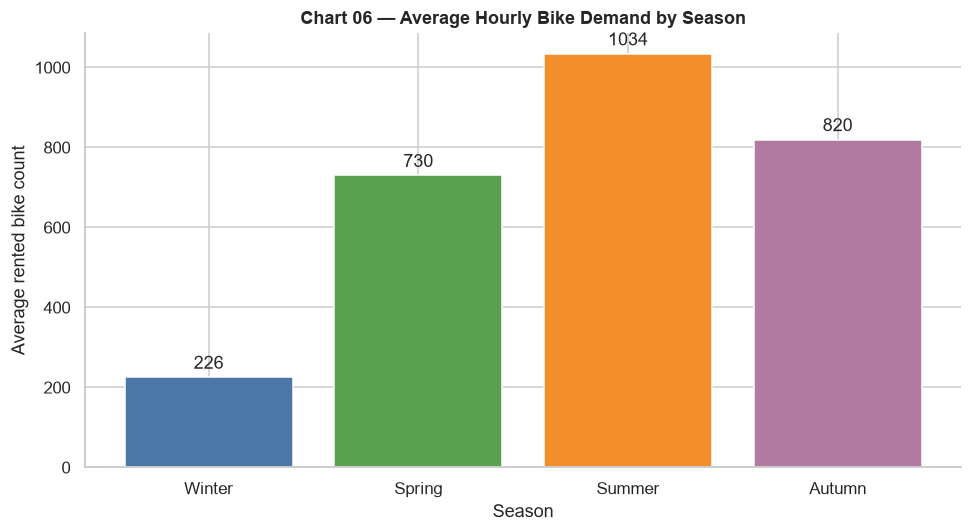

In [19]:
season_average = (
    df.groupby("Seasons", observed=False)["Rented_Bike_Count"]
      .mean().reindex(SEASON_ORDER).rename("Average_Demand").to_frame()
)
display(season_average.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(season_average.index, season_average["Average_Demand"],
       color=[SEASON_COLORS[s] for s in season_average.index])
ax.set(title="Chart 06 — Average Hourly Bike Demand by Season",
       xlabel="Season", ylabel="Average rented bike count")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

**Nhận xét mùa:** Summer có demand trung bình cao nhất (1.034,1 lượt/giờ), theo sau là Autumn và Spring; Winter thấp nhất (225,5). Box/violin plot cũng cho thấy độ phân tán và phần đuôi cao khác nhau rõ giữa các mùa, vì vậy chỉ nhìn mean là chưa đủ.

### Chart 07 — Horizontal Bar Chart: Weekday Ranking

,Average_Demand
Day_Name,
Friday,747.12
Wednesday,740.35
Monday,730.56
Saturday,709.53
Thursday,690.70
Tuesday,687.98
Sunday,625.16


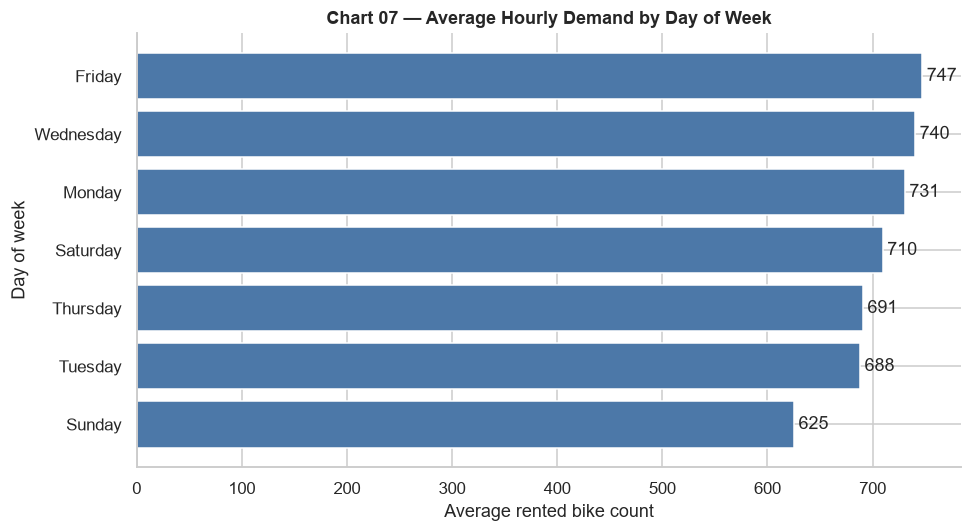

In [20]:
weekday_average = (
    df.groupby("Day_Name", observed=False)["Rented_Bike_Count"]
      .mean().sort_values(ascending=False).rename("Average_Demand").to_frame()
)
display(weekday_average.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(weekday_average.index, weekday_average["Average_Demand"],
               color="#4C78A8")
ax.invert_yaxis()
ax.set(title="Chart 07 — Average Hourly Demand by Day of Week",
       xlabel="Average rented bike count", ylabel="Day of week")
ax.bar_label(bars, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

**Nhận xét:** Friday đứng đầu với khoảng 747,1 lượt/giờ, còn Sunday thấp nhất với 625,2. Trung bình ngày thường (719,4) cao hơn cuối tuần (667,3), nhưng chênh lệch giữa từng ngày cho thấy không nên gộp mọi ngày cuối tuần thành cùng một hành vi.

### Chart 08 — Grouped Bar Chart: Holiday Status within Seasons

Holiday,No Holiday,Holiday
Seasons,,
Winter,232.26,156.62
Spring,733.22,635.31
Summer,1034.34,1022.15
Autumn,823.15,758.48


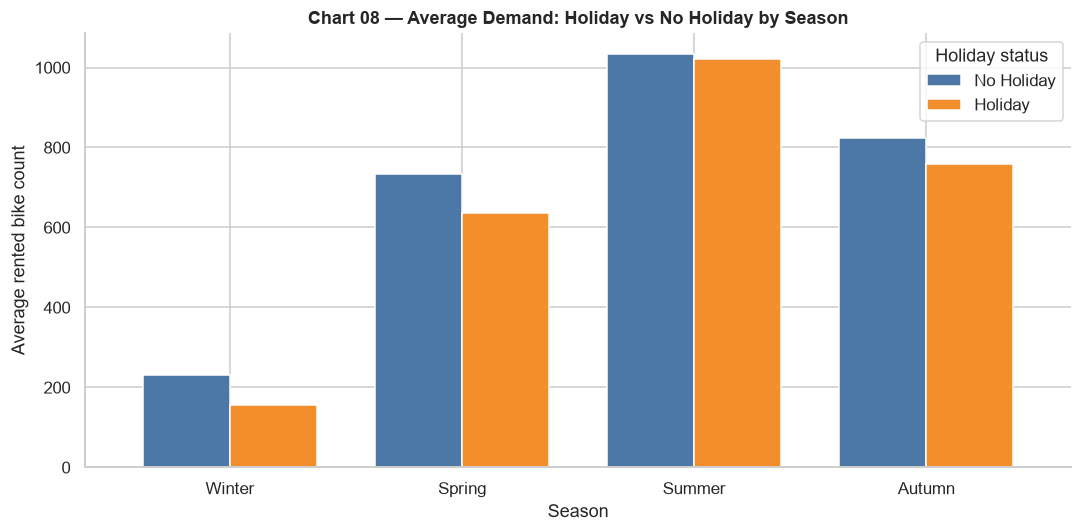

In [21]:
season_holiday = (
    df.groupby(["Seasons", "Holiday"], observed=False)["Rented_Bike_Count"]
      .mean().unstack("Holiday").reindex(SEASON_ORDER)
)
display(season_holiday.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
season_holiday[["No Holiday", "Holiday"]].plot(
    kind="bar", color=["#4C78A8", "#F28E2B"], width=0.75, ax=ax
)
ax.set(title="Chart 08 — Average Demand: Holiday vs No Holiday by Season",
       xlabel="Season", ylabel="Average rented bike count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Holiday status")
plt.tight_layout()
plt.show()

### Chart 09 — 100% Stacked Bar: Time-of-Day Demand Share by Season

TimeOfDay,Night,Morning,Afternoon,Evening
Seasons,,,,
Winter,11.48,25.75,32.75,30.01
Spring,8.32,21.39,33.77,36.51
Summer,11.75,21.07,25.67,41.51
Autumn,9.96,21.97,31.72,36.35


Row sums (%): {'Winter': 100.0, 'Spring': 100.0, 'Summer': 100.0, 'Autumn': 100.0}


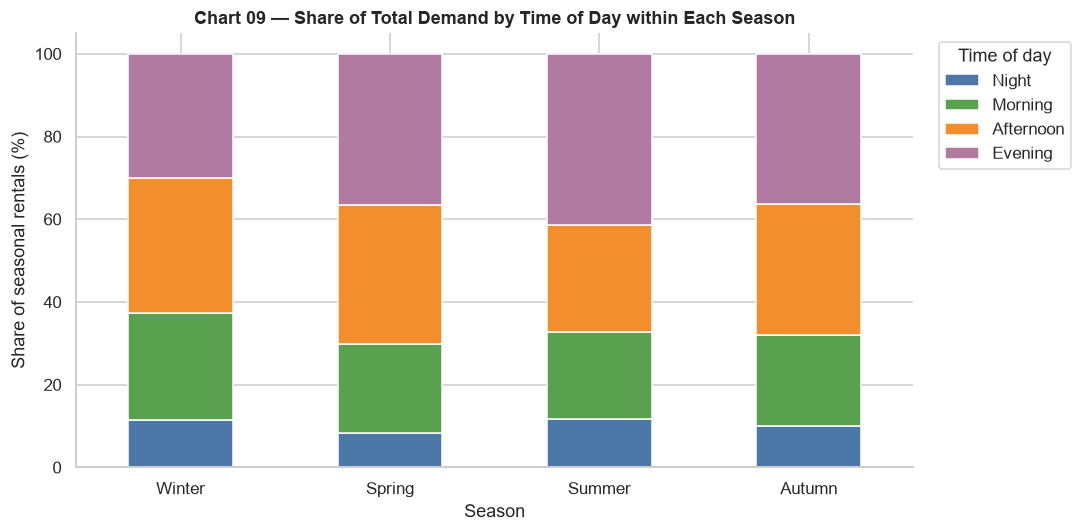

In [22]:
season_time_total = (
    df.groupby(["Seasons", "TimeOfDay"], observed=False)["Rented_Bike_Count"]
      .sum().unstack("TimeOfDay").reindex(index=SEASON_ORDER, columns=TIME_ORDER)
)
season_time_share = season_time_total.div(season_time_total.sum(axis=1), axis=0).mul(100)
display(season_time_share.round(2))
print("Row sums (%):", season_time_share.sum(axis=1).round(6).to_dict())

fig, ax = plt.subplots(figsize=(10, 5))
season_time_share.plot(kind="bar", stacked=True,
                       color=["#4C78A8", "#59A14F", "#F28E2B", "#B07AA1"], ax=ax)
ax.set(title="Chart 09 — Share of Total Demand by Time of Day within Each Season",
       xlabel="Season", ylabel="Share of seasonal rentals (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Time of day", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Nhận xét:** Trong cả bốn mùa, Afternoon và Evening chiếm phần lớn tổng demand; các tỷ lệ trong mỗi mùa cộng lại đúng 100%. Holiday đi kèm demand trung bình thấp hơn No Holiday trong dữ liệu tổng thể, nhưng Chart 08 giúp kiểm tra khác biệt đó trong từng mùa thay vì chỉ dựa vào một con số gộp.

### Chart 10 — Line Chart: Daily Total Demand

,Date,Daily_Demand
0,2017-12-01,9539
1,2017-12-02,8523
2,2017-12-03,7222
3,2017-12-04,8729
4,2017-12-05,8307


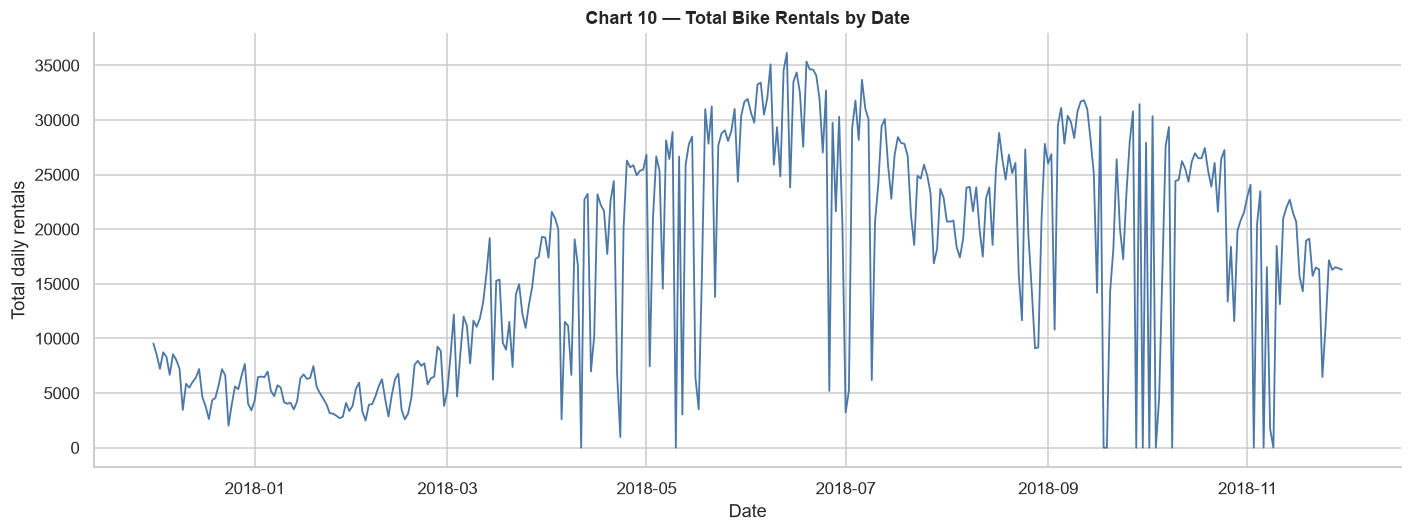

In [23]:
daily_demand = (
    df.groupby("Date", as_index=False)["Rented_Bike_Count"]
      .sum().rename(columns={"Rented_Bike_Count": "Daily_Demand"})
)
display(daily_demand.head())

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_demand["Date"], daily_demand["Daily_Demand"],
        color="#4C78A8", linewidth=1.2)
ax.set(title="Chart 10 — Total Bike Rentals by Date",
       xlabel="Date", ylabel="Total daily rentals")
plt.tight_layout()
plt.show()

### Chart 11 — Multi-line Chart: Hourly Demand Profiles by Season

Seasons,Winter,Spring,Summer,Autumn
Hour,,,,
0,165.18,470.63,899.07,623.68
1,159.06,356.03,698.77,485.71
2,117.79,247.47,505.75,331.85
3,77.81,164.82,342.67,225.54
4,50.48,105.87,223.82,148.59
5,51.22,113.65,245.93,143.66
6,92.82,251.64,485.84,316.03
7,209.57,601.91,902.78,702.19
8,422.20,1013.85,1418.60,1197.23


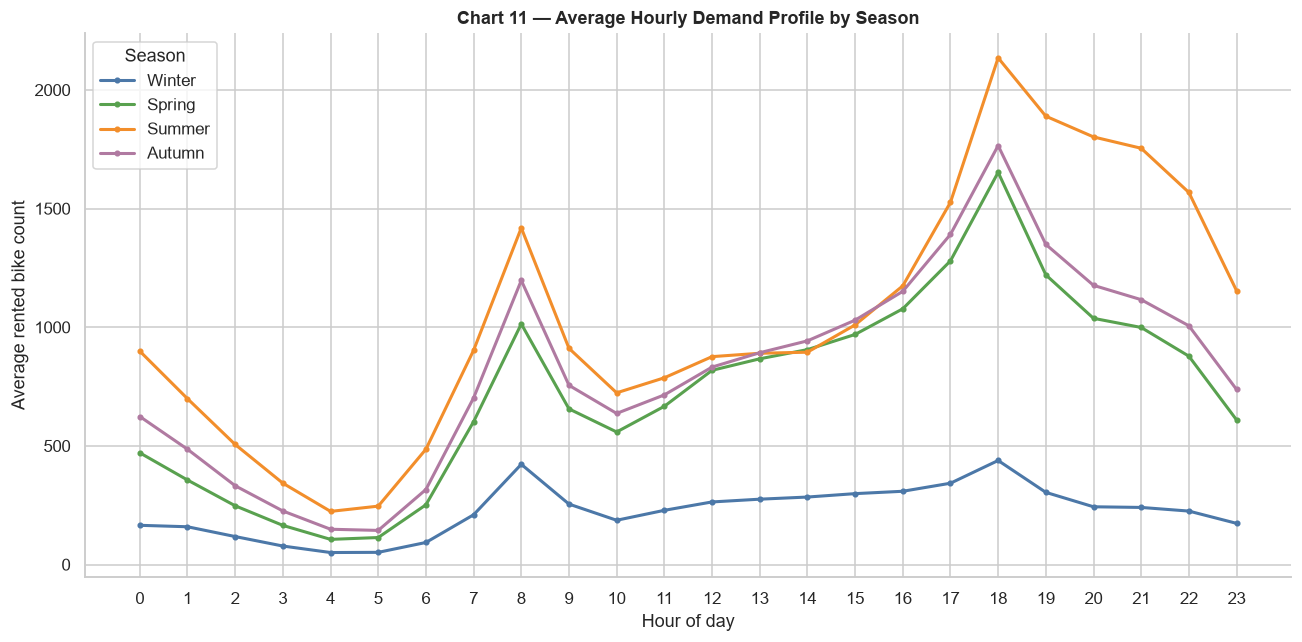

In [24]:
hour_season = (
    df.groupby(["Hour", "Seasons"], observed=False)["Rented_Bike_Count"]
      .mean().unstack("Seasons").reindex(columns=SEASON_ORDER)
)
display(hour_season.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
for season in SEASON_ORDER:
    ax.plot(hour_season.index, hour_season[season], marker="o", markersize=3,
            linewidth=2, label=season, color=SEASON_COLORS[season])
ax.set(title="Chart 11 — Average Hourly Demand Profile by Season",
       xlabel="Hour of day", ylabel="Average rented bike count", xticks=range(24))
ax.legend(title="Season")
plt.tight_layout()
plt.show()

### Chart 12 — Area Chart: Daily Demand and 7-Day Rolling Average

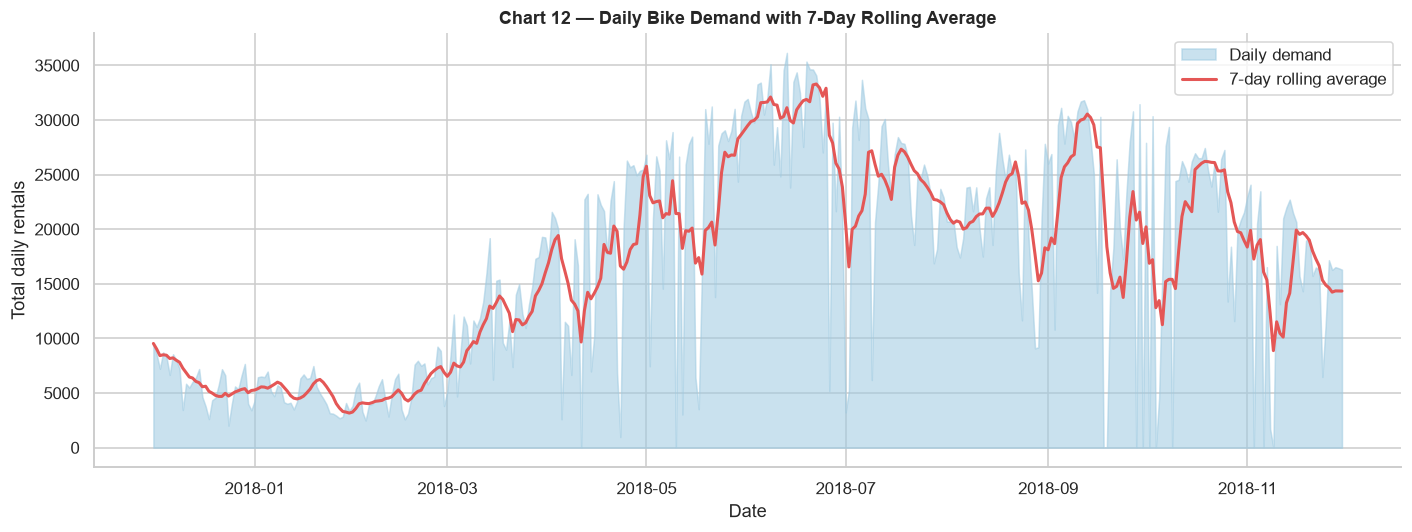

In [25]:
daily_demand["Rolling_7D"] = daily_demand["Daily_Demand"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(daily_demand["Date"], daily_demand["Daily_Demand"],
                color="#9ECAE1", alpha=0.55, label="Daily demand")
ax.plot(daily_demand["Date"], daily_demand["Rolling_7D"],
        color="#E45756", linewidth=2, label="7-day rolling average")
ax.set(title="Chart 12 — Daily Bike Demand with 7-Day Rolling Average",
       xlabel="Date", ylabel="Total daily rentals")
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét thời gian:** Demand tăng từ Winter sang Spring/Summer và giảm trở lại về cuối chu kỳ. Hồ sơ theo giờ có đỉnh buổi sáng và đặc biệt rõ vào 18 giờ; đường rolling 7 ngày làm nổi bật xu hướng nền nhưng vẫn giữ các ngày sụt giảm đột ngột trong chuỗi gốc.

### Chart 13 — Scatter Plot: Temperature vs Demand

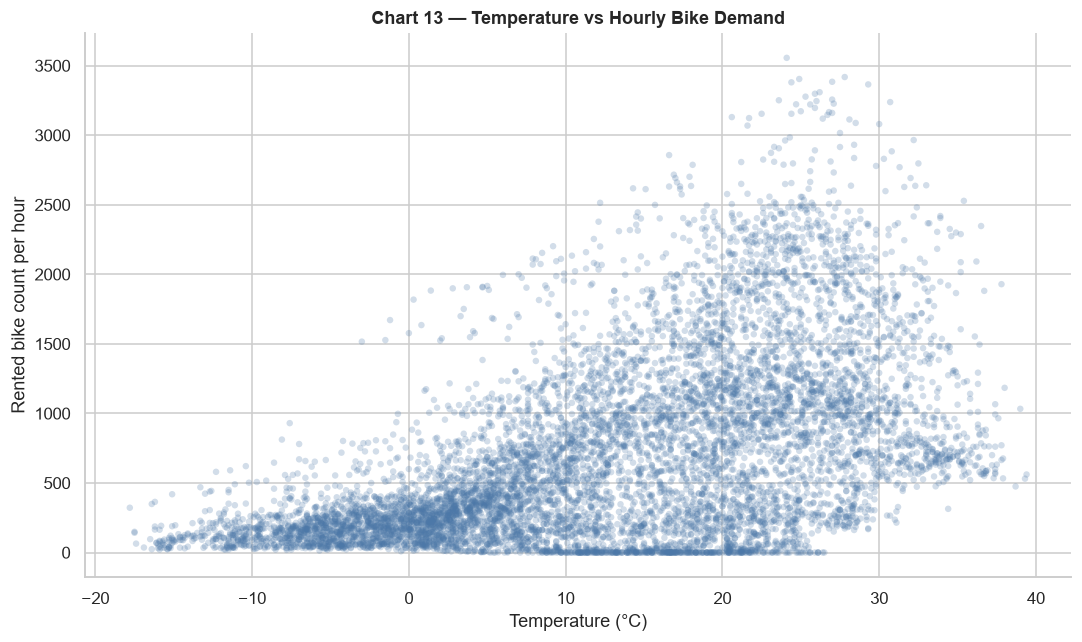

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Temperature"], df["Rented_Bike_Count"], s=18, alpha=0.25,
           color="#4C78A8", edgecolors="none")
ax.set(title="Chart 13 — Temperature vs Hourly Bike Demand",
       xlabel="Temperature (°C)", ylabel="Rented bike count per hour")
plt.tight_layout()
plt.show()

### Chart 14 — Regression Plot: Temperature and Demand

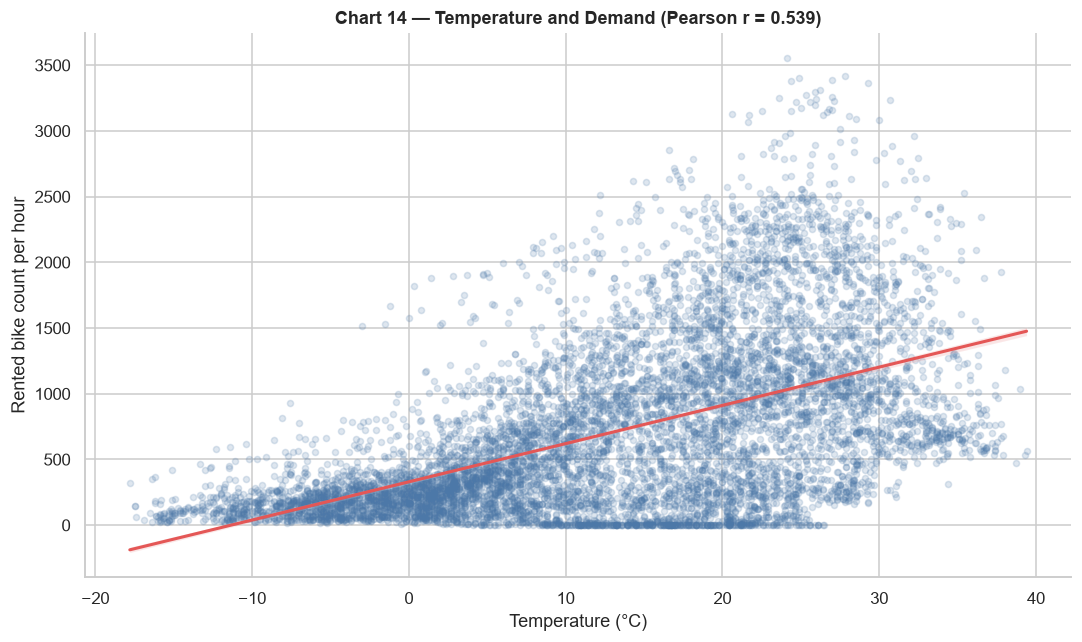

Pearson correlation: 0.5386


In [27]:
temperature_correlation = df["Temperature"].corr(df["Rented_Bike_Count"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="Temperature", y="Rented_Bike_Count",
            scatter_kws={"alpha": 0.18, "s": 16, "color": "#4C78A8"},
            line_kws={"color": "#E45756", "linewidth": 2}, ax=ax)
ax.set(title=f"Chart 14 — Temperature and Demand (Pearson r = {temperature_correlation:.3f})",
       xlabel="Temperature (°C)", ylabel="Rented bike count per hour")
plt.tight_layout()
plt.show()
print(f"Pearson correlation: {temperature_correlation:.4f}")

**Nhận xét:** Temperature và demand có tương quan Pearson dương mức vừa (r ≈ 0,539). Đường hồi quy mô tả xu hướng liên hệ tuyến tính quan sát được, không phải bằng chứng rằng nhiệt độ gây ra thay đổi demand.

### Chart 15 — Bubble Chart: Temperature, Demand, and Humidity

Visualization-only sample: 3,000 rows; all statistics use the full dataset.


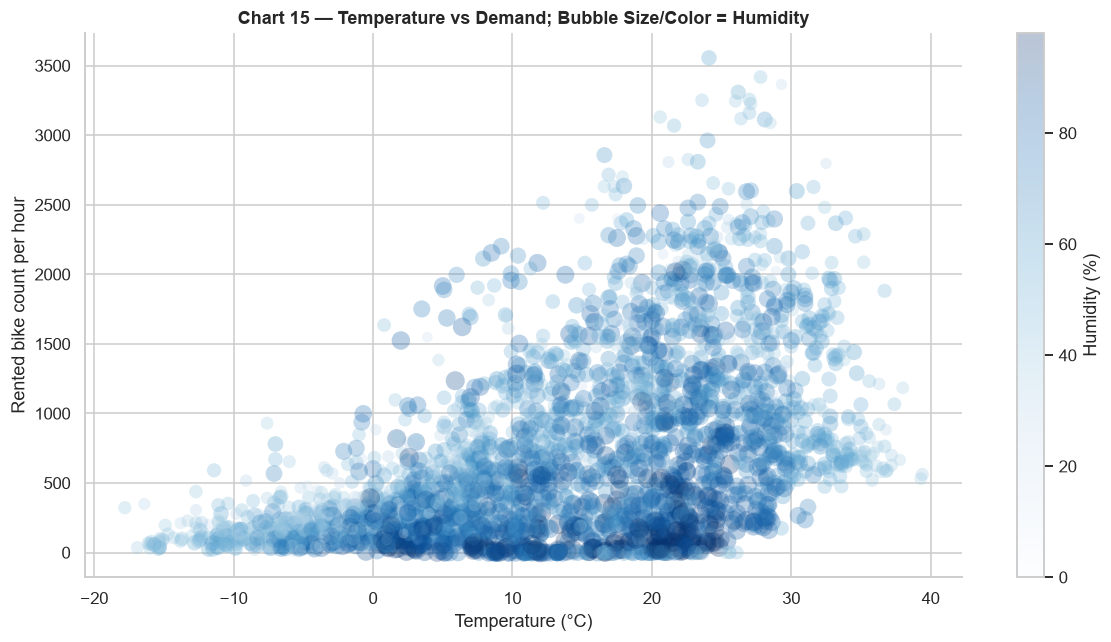

In [28]:
bubble_sample_size = min(3000, len(df))
bubble_data = df.sample(n=bubble_sample_size, random_state=RANDOM_STATE)
bubble_sizes = 12 + bubble_data["Humidity"] * 1.6

print(f"Visualization-only sample: {bubble_sample_size:,} rows; all statistics use the full dataset.")
fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(
    bubble_data["Temperature"], bubble_data["Rented_Bike_Count"],
    s=bubble_sizes, c=bubble_data["Humidity"], cmap="Blues",
    alpha=0.28, edgecolors="none",
)
ax.set(title="Chart 15 — Temperature vs Demand; Bubble Size/Color = Humidity",
       xlabel="Temperature (°C)", ylabel="Rented bike count per hour")
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Humidity (%)")
plt.tight_layout()
plt.show()

### Chart 16 — Hexbin Plot: Density of Temperature and Demand

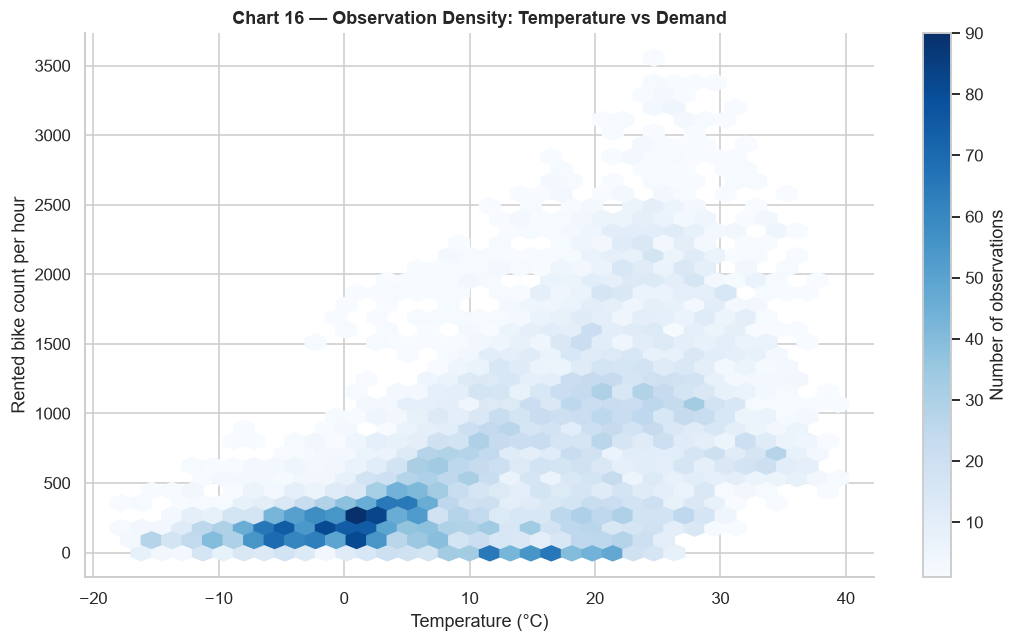

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
hex_plot = ax.hexbin(df["Temperature"], df["Rented_Bike_Count"],
                     gridsize=35, mincnt=1, cmap="Blues")
ax.set(title="Chart 16 — Observation Density: Temperature vs Demand",
       xlabel="Temperature (°C)", ylabel="Rented bike count per hour")
colorbar = fig.colorbar(hex_plot, ax=ax)
colorbar.set_label("Number of observations")
plt.tight_layout()
plt.show()

**Nhận xét:** Bubble và hexbin giúp nhìn rõ vùng điểm dày vốn bị che lấp trong scatter plot. Các mức humidity cao xuất hiện ở nhiều dải nhiệt độ và demand; cần xem cùng heatmap tương quan để tránh suy diễn từ một vài bubble riêng lẻ.

## 8. Multivariate Analysis

Xem đồng thời nhiều biến qua ma trận tương quan, heatmap theo lịch, pair plot, cơ cấu mùa và radar đã chuẩn hóa.

### Chart 17 — Correlation Heatmap

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Dew_Point_Temperature,Solar_Radiation,Rainfall,Snowfall,Temperature_DewPoint_Diff
Rented_Bike_Count,1.000,0.410,0.539,-0.200,0.121,0.199,0.380,0.262,-0.123,-0.142,0.276
Hour,0.410,1.000,0.124,-0.242,0.285,0.099,0.003,0.145,0.009,-0.022,0.270
Temperature,0.539,0.124,1.000,0.159,-0.036,0.035,0.913,0.354,0.050,-0.218,0.004
Humidity,-0.200,-0.242,0.159,1.000,-0.337,-0.543,0.537,-0.462,0.236,0.108,-0.958
Wind_Speed,0.121,0.285,-0.036,-0.337,1.000,0.172,-0.176,0.332,-0.020,-0.004,0.351
Visibility,0.199,0.099,0.035,-0.543,0.172,1.000,-0.177,0.150,-0.168,-0.122,0.510
Dew_Point_Temperature,0.380,0.003,0.913,0.537,-0.176,-0.177,1.000,0.094,0.126,-0.151,-0.404
Solar_Radiation,0.262,0.145,0.354,-0.462,0.332,0.150,0.094,1.000,-0.074,-0.072,0.561
Rainfall,-0.123,0.009,0.050,0.236,-0.020,-0.168,0.126,-0.074,1.000,0.008,-0.195
Snowfall,-0.142,-0.022,-0.218,0.108,-0.004,-0.122,-0.151,-0.072,0.008,1.000,-0.120


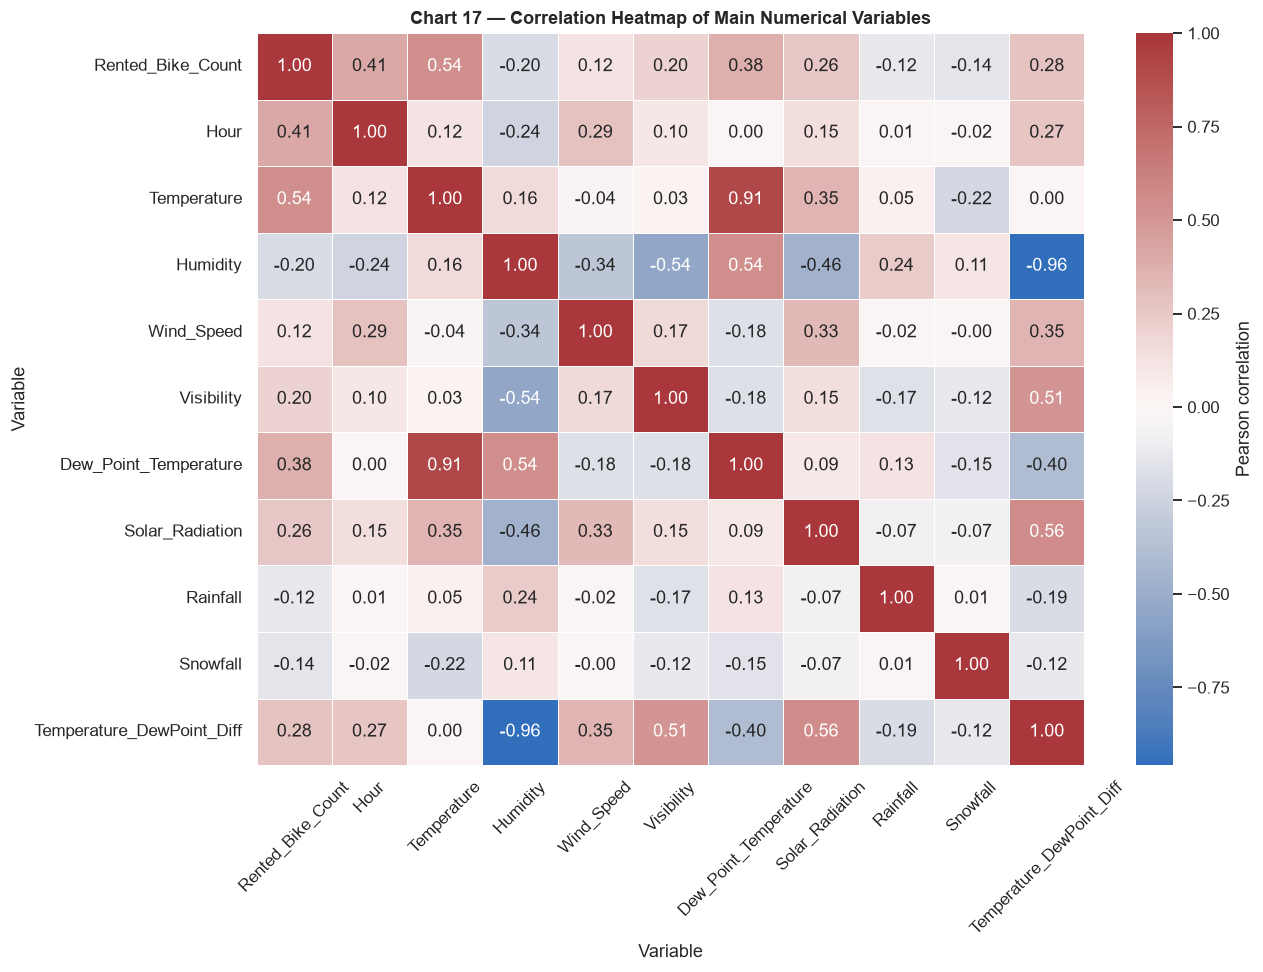

In [30]:
correlation_columns = [
    "Rented_Bike_Count", "Hour", "Temperature", "Humidity", "Wind_Speed",
    "Visibility", "Dew_Point_Temperature", "Solar_Radiation", "Rainfall", "Snowfall",
    "Temperature_DewPoint_Diff",
]
correlation_matrix = df[correlation_columns].corr()
display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set(title="Chart 17 — Correlation Heatmap of Main Numerical Variables",
       xlabel="Variable", ylabel="Variable")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:** Temperature có tương quan dương rõ nhất với demand trong nhóm thời tiết được xem xét, trong khi Humidity có tương quan âm khoảng -0,200. Temperature và Dew Point Temperature tương quan rất mạnh với nhau, nên các hệ số không nên được đọc như các tác động độc lập.

### Chart 18 — Hour × Weekday Heatmap

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day_Name,,,,,,,,,,,,,,,,,,,,,
Monday,459.6,296.2,199.9,132.8,103.2,157.4,370.3,797.5,1268.9,703.8,...,712.5,782.6,908.3,1173.2,1695.0,1294.5,1181.2,1134.2,980.9,695.0
Tuesday,473.5,380.4,260.3,170.7,115.1,140.8,334.8,754.9,1276.3,715.5,...,667.8,701.7,816.6,1054.5,1552.3,1165.5,1013.2,1008.9,900.2,599.9
Wednesday,505.8,396.2,277.4,191.8,126.7,141.7,321.1,727.5,1250.1,722.7,...,740.6,807.2,921.3,1194.9,1668.1,1278.1,1135.2,1084.2,965.0,675.3
Thursday,520.1,414.8,289.5,184.3,118.9,142.3,321.1,705.0,1196.5,671.4,...,646.6,708.3,803.5,1047.6,1605.0,1215.9,1045.4,1029.1,940.6,663.1
Friday,529.1,431.7,287.1,192.8,125.5,147.6,346.4,754.0,1287.5,708.3,...,701.0,799.3,925.0,1220.4,1767.5,1326.5,1111.2,1049.1,987.3,758.9
Saturday,663.6,597.2,439.0,299.8,184.8,138.8,186.6,295.1,487.1,567.4,...,959.2,1046.8,1116.0,1208.7,1159.0,1062.8,1006.0,993.6,908.4,735.4
Sunday,638.8,466.8,358.5,251.3,154.1,104.8,131.4,205.2,338.3,431.6,...,885.0,959.1,1023.9,1068.7,1068.5,1020.2,989.8,920.7,776.0,568.6


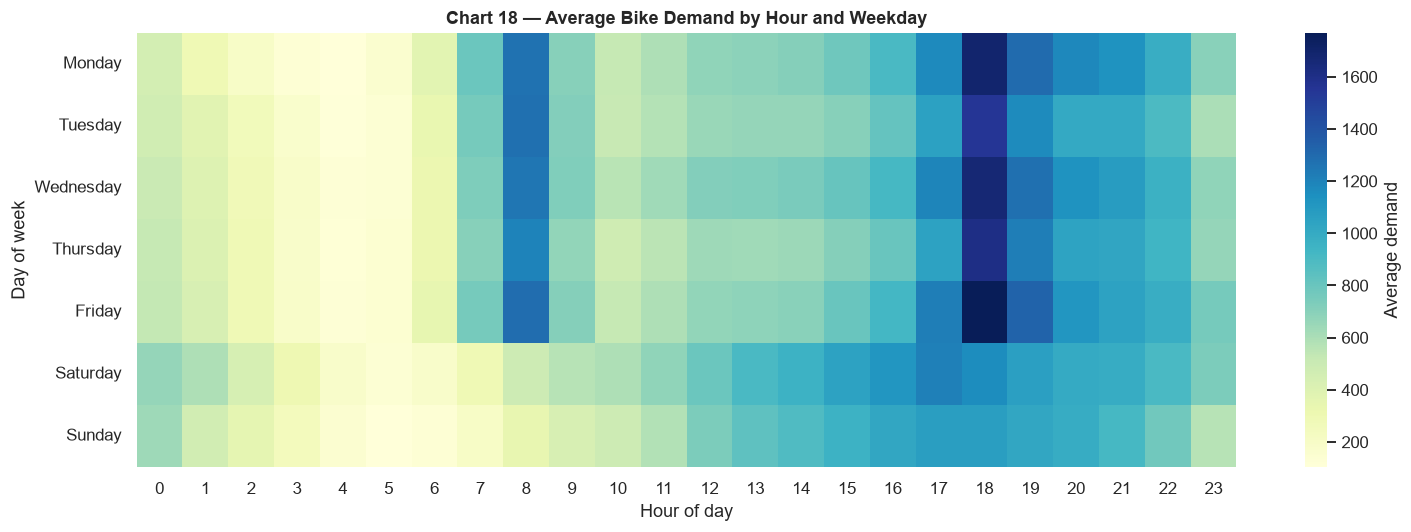

In [31]:
weekday_hour = (
    df.pivot_table(index="Day_Name", columns="Hour", values="Rented_Bike_Count",
                   aggfunc="mean", observed=False)
      .reindex(index=DAY_ORDER, columns=range(24))
)
display(weekday_hour.round(1))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(weekday_hour, cmap="YlGnBu", cbar_kws={"label": "Average demand"}, ax=ax)
ax.set(title="Chart 18 — Average Bike Demand by Hour and Weekday",
       xlabel="Hour of day", ylabel="Day of week")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:** Heatmap cho thấy các ngày làm việc có hai dải demand nổi bật quanh giờ đi làm và tan làm, trong đó 18 giờ là đỉnh mạnh nhất. Cuối tuần có profile phẳng hơn và demand dịch nhiều hơn về ban ngày/chiều.

### Chart 19 — Month × Hour Heatmap

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Month,,,,,,,,,,,,,,,,,,,,,
1,144.1,138.0,101.7,64.9,43.4,48.6,89.5,194.8,397.4,240.1,...,251.9,257.0,257.5,299.3,385.6,266.4,221.4,218.6,201.6,148.6
2,146.9,140.4,100.0,67.0,45.9,44.6,94.1,217.3,426.6,253.0,...,285.6,310.9,319.6,358.2,471.1,317.7,244.6,239.1,220.5,162.8
3,295.4,243.5,172.6,110.7,73.5,73.6,157.9,421.6,749.4,489.5,...,695.9,782.8,822.1,917.5,1174.8,795.5,653.0,621.1,550.8,369.2
4,474.3,346.4,237.4,155.1,98.7,108.5,254.5,622.5,1070.0,661.1,...,908.6,932.8,1052.3,1253.4,1657.8,1184.3,1028.1,973.8,854.1,599.9
5,642.3,477.9,332.1,228.3,145.2,158.7,342.6,762.3,1224.0,817.0,...,1112.2,1191.5,1357.3,1666.9,2125.3,1680.8,1431.0,1401.0,1228.1,858.9
6,989.2,766.3,567.1,369.0,240.7,257.8,509.5,1031.4,1606.9,1086.5,...,1259.9,1404.4,1613.0,1994.4,2494.5,2212.1,2088.7,1984.5,1782.6,1315.7
7,881.6,692.4,503.4,351.1,229.7,261.4,502.2,903.1,1400.6,865.9,...,775.2,863.1,1029.3,1385.2,2085.9,1824.8,1772.6,1747.5,1557.5,1128.7
8,829.3,639.8,448.8,308.7,201.6,219.0,446.5,778.0,1254.4,786.2,...,660.6,774.4,894.4,1214.4,1836.6,1641.2,1553.7,1537.6,1370.5,1022.5
9,763.4,592.4,394.8,265.1,175.9,165.1,353.2,725.8,1145.3,765.0,...,1041.6,1140.8,1299.8,1590.9,2009.9,1643.6,1486.1,1397.9,1236.1,921.1


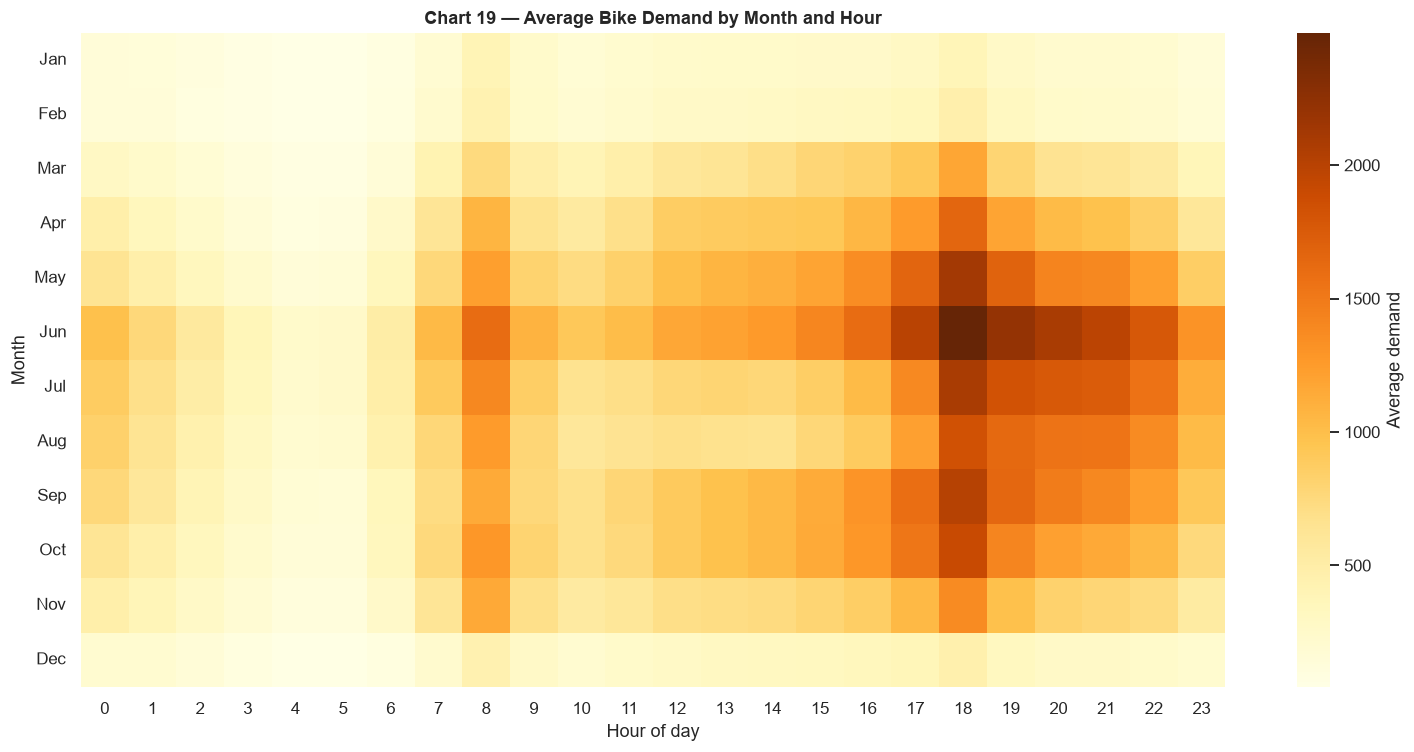

In [32]:
month_hour = (
    df.pivot_table(index="Month", columns="Hour", values="Rented_Bike_Count",
                   aggfunc="mean", observed=False)
      .reindex(index=range(1, 13), columns=range(24))
)
display(month_hour.round(1))

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(month_hour, cmap="YlOrBr", cbar_kws={"label": "Average demand"}, ax=ax)
ax.set(title="Chart 19 — Average Bike Demand by Month and Hour",
       xlabel="Hour of day", ylabel="Month")
ax.set_yticklabels([pd.Timestamp(2024, month, 1).strftime("%b") for month in range(1, 13)], rotation=0)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:** Demand theo giờ thấp rõ trong các tháng mùa đông và cao hơn từ cuối xuân đến đầu thu. Dải màu mạnh vào cuối buổi chiều/đầu buổi tối tồn tại qua nhiều tháng, nhưng cường độ thay đổi theo mùa.

### Chart 20 — Pair Plot of Selected Variables

Visualization-only sample: 2,000 rows; all statistics use the full dataset.


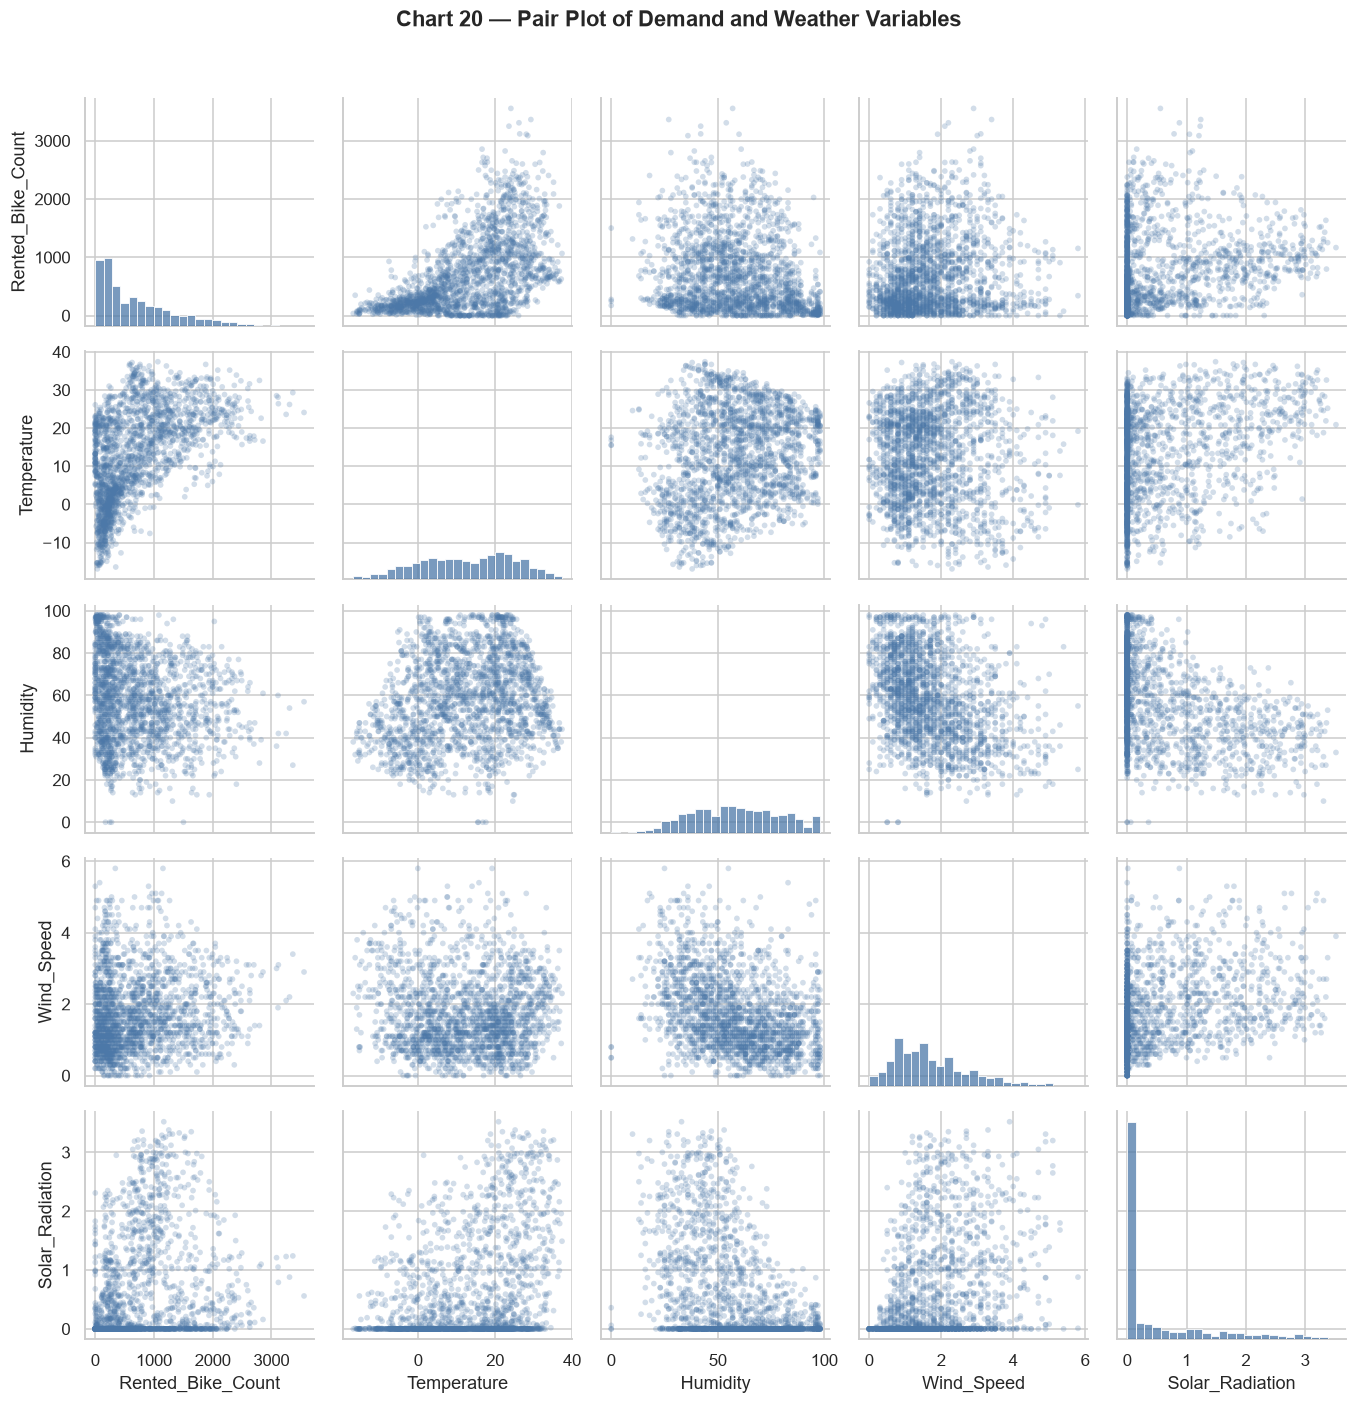

In [33]:
pair_columns = [
    "Rented_Bike_Count", "Temperature", "Humidity", "Wind_Speed", "Solar_Radiation"
]
pair_sample_size = min(2000, len(df))
pair_data = df[pair_columns].sample(n=pair_sample_size, random_state=RANDOM_STATE)
print(f"Visualization-only sample: {pair_sample_size:,} rows; all statistics use the full dataset.")

pair_grid = sns.pairplot(
    pair_data, diag_kind="hist",
    plot_kws={"alpha": 0.25, "s": 14, "color": "#4C78A8", "edgecolor": "none"},
    diag_kws={"bins": 25, "color": "#4C78A8"},
)
pair_grid.figure.suptitle("Chart 20 — Pair Plot of Demand and Weather Variables", y=1.02, fontweight="bold")
pair_grid.figure.tight_layout()
plt.show()

**Nhận xét:** Pair plot củng cố xu hướng demand tăng cùng Temperature và giảm nhẹ khi Humidity cao, đồng thời cho thấy quan hệ không hoàn toàn tuyến tính và độ phân tán lớn. Sampling chỉ phục vụ tốc độ render; mọi bảng thống kê vẫn dùng đủ 8.760 dòng.

### Chart 21 — Donut Chart: Share of Total Rentals by Season

,Total_Rentals,Share_Percent
Seasons,,
Winter,487169,7.89
Spring,1611909,26.12
Summer,2283234,36.99
Autumn,1790002,29.00


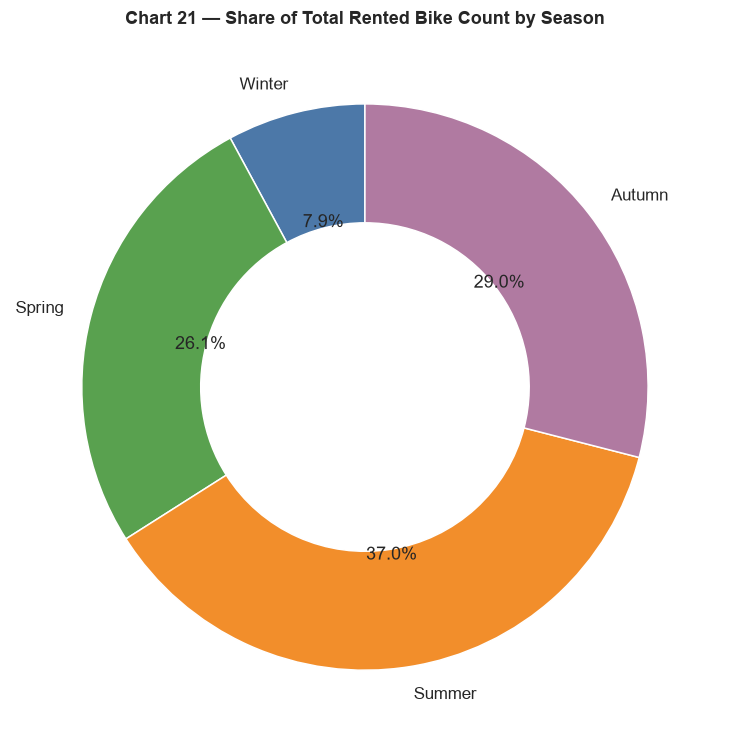

In [34]:
season_total = (
    df.groupby("Seasons", observed=False)["Rented_Bike_Count"]
      .sum().reindex(SEASON_ORDER).rename("Total_Rentals").to_frame()
)
season_total["Share_Percent"] = season_total["Total_Rentals"].div(
    season_total["Total_Rentals"].sum()
).mul(100)
display(season_total.round(2))

fig, ax = plt.subplots(figsize=(8, 7))
ax.pie(season_total["Total_Rentals"], labels=season_total.index, autopct="%1.1f%%",
       startangle=90, colors=[SEASON_COLORS[s] for s in season_total.index],
       wedgeprops={"width": 0.42, "edgecolor": "white"})
ax.set_title("Chart 21 — Share of Total Rented Bike Count by Season")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**Nhận xét:** Donut chart dùng tổng lượt thuê, không dùng số dòng. Summer đóng góp tỷ trọng lớn nhất trong toàn bộ 6.172.314 lượt thuê, còn Winter chiếm tỷ trọng nhỏ nhất.

### Chart 23 — Radar Chart: Normalized Seasonal Weather Profiles

,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Rainfall
Seasons,,,,,,
Winter,-2.540,49.745,1.923,1445.987,0.298,0.033
Spring,13.047,58.777,1.875,1240.365,0.689,0.183
Summer,26.583,64.981,1.609,1501.745,0.761,0.253
Autumn,14.121,59.228,1.495,1560.752,0.522,0.123


,Normalized_Temperature,Normalized_Humidity,Normalized_Wind_Speed,Normalized_Visibility,Normalized_Solar_Radiation,Normalized_Rainfall
Seasons,,,,,,
Winter,0.000,0.000,1.000,0.642,0.000,0.000
Spring,0.535,0.593,0.888,0.000,0.844,0.680
Summer,1.000,1.000,0.268,0.816,1.000,1.000
Autumn,0.572,0.622,0.000,1.000,0.483,0.408


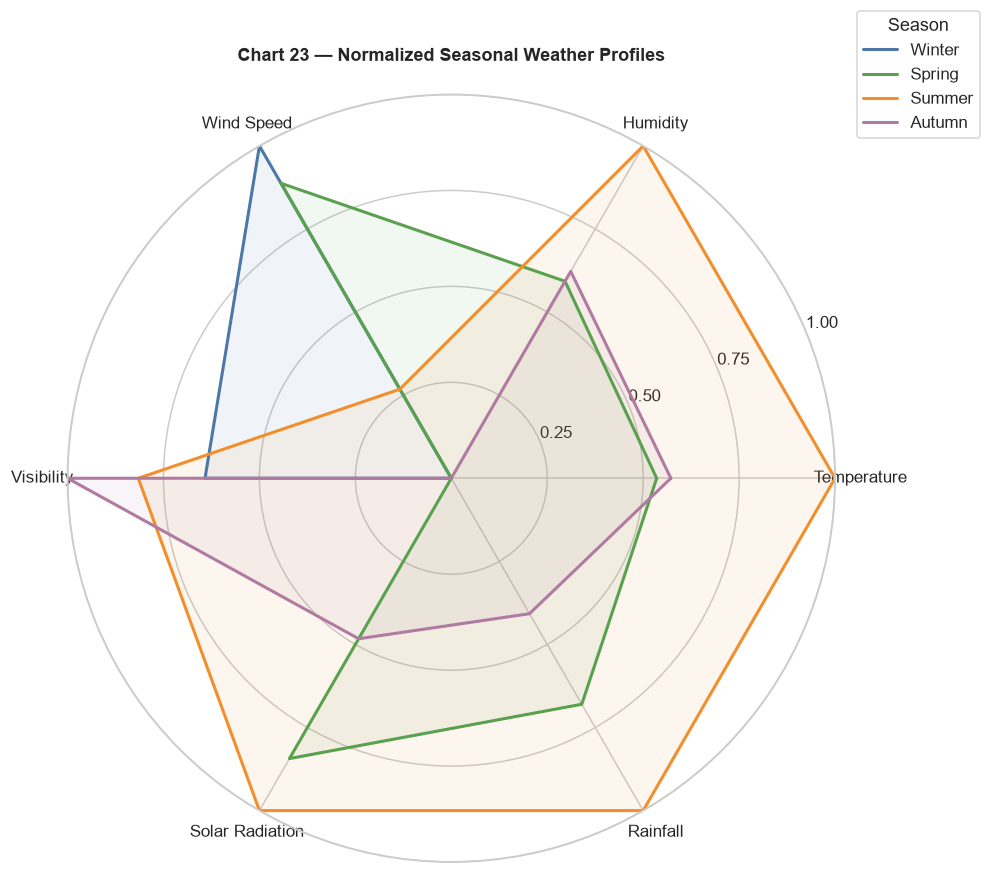

In [35]:
radar_metrics = [
    "Temperature", "Humidity", "Wind_Speed",
    "Visibility", "Solar_Radiation", "Rainfall",
]
season_weather_raw = (
    df.groupby("Seasons", observed=False)[radar_metrics]
      .mean().reindex(SEASON_ORDER)
)
metric_ranges = season_weather_raw.max() - season_weather_raw.min()
season_weather_normalized = (
    (season_weather_raw - season_weather_raw.min())
    .div(metric_ranges.replace(0, 1))
)
display(season_weather_raw.round(3))
display(season_weather_normalized.round(3).add_prefix("Normalized_"))

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw={"polar": True})
for season in SEASON_ORDER:
    values = season_weather_normalized.loc[season].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=season, color=SEASON_COLORS[season])
    ax.fill(angles, values, alpha=0.08, color=SEASON_COLORS[season])
ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.replace("_", " ") for m in radar_metrics])
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title("Chart 23 — Normalized Seasonal Weather Profiles", pad=22)
ax.legend(title="Season", bbox_to_anchor=(1.20, 1.12))
plt.tight_layout()
plt.show()

**Nhận xét:** Radar sử dụng Min–Max normalization riêng cho từng metric (0–1), không phải giá trị raw. Nó cho phép so sánh hình dạng profile: Summer nổi bật về nhiệt độ và mưa trung bình tương đối, còn Winter ở cực thấp của nhiệt độ; khoảng cách trên radar chỉ có ý nghĩa tương đối trong từng metric.

## 9. Time Series Analysis

Charts 10–12 đã mô tả chuỗi daily demand và rolling average. Phần này bổ sung calendar heatmap toàn bộ 365 ngày và bảng thống kê tóm tắt theo thời gian.

### Chart 22 — Calendar-Style Heatmap: Daily Bike Demand

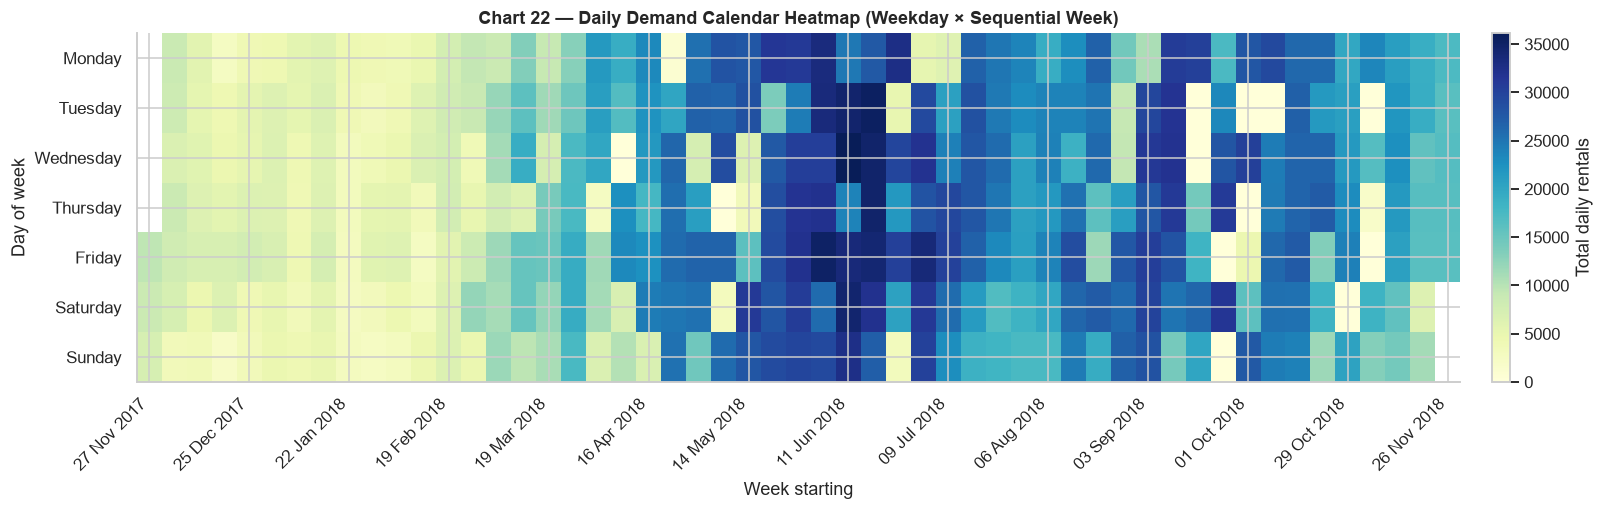

In [36]:
calendar_data = daily_demand[["Date", "Daily_Demand"]].copy()
calendar_start = calendar_data["Date"].min() - pd.to_timedelta(
    calendar_data["Date"].min().dayofweek, unit="D"
)
calendar_data["Week_Index"] = (
    (calendar_data["Date"] - calendar_start).dt.days // 7
).astype(int)
calendar_data["Weekday"] = calendar_data["Date"].dt.dayofweek
calendar_matrix = calendar_data.pivot(
    index="Weekday", columns="Week_Index", values="Daily_Demand"
).reindex(index=range(7))

fig, ax = plt.subplots(figsize=(16, 4.8))
heatmap = ax.imshow(calendar_matrix, aspect="auto", cmap="YlGnBu", interpolation="nearest")
ax.set_yticks(range(7), DAY_ORDER)
tick_positions = np.arange(0, calendar_matrix.shape[1], 4)
tick_labels = [(calendar_start + pd.Timedelta(weeks=int(w))).strftime("%d %b %Y")
               for w in tick_positions]
ax.set_xticks(tick_positions, tick_labels, rotation=45, ha="right")
ax.set(title="Chart 22 — Daily Demand Calendar Heatmap (Weekday × Sequential Week)",
       xlabel="Week starting", ylabel="Day of week")
colorbar = fig.colorbar(heatmap, ax=ax, pad=0.02)
colorbar.set_label("Total daily rentals")
plt.tight_layout()
plt.show()

**Nhận xét:** Calendar heatmap bao phủ toàn bộ khoảng 01/12/2017–30/11/2018. Demand cao tập trung nhiều hơn trong giai đoạn ấm, xen kẽ một số ngày giảm rất mạnh; ngày 11/04/2018 có tổng bằng 0 do toàn bộ 24 giờ được ghi là non-functioning, không phải missing data.

In [37]:
hour_average = df.groupby("Hour")["Rented_Bike_Count"].mean()
season_average_series = df.groupby("Seasons", observed=False)["Rented_Bike_Count"].mean()
weekday_average_ordered = df.groupby("Day_Name", observed=False)["Rented_Bike_Count"].mean()
holiday_average = df.groupby("Holiday", observed=False)["Rented_Bike_Count"].mean()
functioning_average = df.groupby("Functioning_Day", observed=False)["Rented_Bike_Count"].mean()

summary_statistics = pd.DataFrame({
    "Statistic": [
        "Total rentals", "Average rentals / hour", "Median rentals / hour",
        "Standard deviation", "Highest-demand date", "Highest daily total",
        "Lowest-demand date", "Lowest daily total", "Peak average hour",
        "Peak average hour demand", "Highest average season", "Highest average weekday",
        "Correlation: Temperature vs demand", "Correlation: Humidity vs demand",
        "Average demand: Holiday", "Average demand: No Holiday",
        "Average demand: Functioning Day", "Average demand: Non-functioning Day",
    ],
    "Value": [
        int(df["Rented_Bike_Count"].sum()),
        round(df["Rented_Bike_Count"].mean(), 2),
        round(df["Rented_Bike_Count"].median(), 2),
        round(df["Rented_Bike_Count"].std(), 2),
        daily_demand.loc[daily_demand["Daily_Demand"].idxmax(), "Date"].strftime("%d/%m/%Y"),
        int(daily_demand["Daily_Demand"].max()),
        daily_demand.loc[daily_demand["Daily_Demand"].idxmin(), "Date"].strftime("%d/%m/%Y"),
        int(daily_demand["Daily_Demand"].min()),
        int(hour_average.idxmax()), round(hour_average.max(), 2),
        str(season_average_series.idxmax()), str(weekday_average_ordered.idxmax()),
        round(df["Temperature"].corr(df["Rented_Bike_Count"]), 4),
        round(df["Humidity"].corr(df["Rented_Bike_Count"]), 4),
        round(holiday_average.loc["Holiday"], 2),
        round(holiday_average.loc["No Holiday"], 2),
        round(functioning_average.loc["Yes"], 2),
        round(functioning_average.loc["No"], 2),
    ],
})
display(summary_statistics)

,Statistic,Value
0,Total rentals,6172314
1,Average rentals / hour,704.6
2,Median rentals / hour,504.5
3,Standard deviation,645.0
4,Highest-demand date,13/06/2018
5,Highest daily total,36149
6,Lowest-demand date,11/04/2018
7,Lowest daily total,0
8,Peak average hour,18
9,Peak average hour demand,1502.93


## 10. Key Insights & Conclusion

1. **Demand lệch phải:** Tổng cộng có **6.172.314** lượt thuê; trung bình **704,6 lượt/giờ** cao hơn median **504,5**, với skewness khoảng **1,15**.
2. **Giờ cao điểm rõ rệt:** **18 giờ** có demand trung bình cao nhất, khoảng **1.502,9 lượt/giờ**. Nhóm rush hour đạt trung bình khoảng **1.017,4**, cao hơn rõ so với **600,3** ngoài rush hour.
3. **Khác biệt theo lịch tuần:** Friday có trung bình cao nhất (**747,1 lượt/giờ**) và Sunday thấp nhất (**625,2**); ngày thường trung bình **719,4**, so với **667,3** cuối tuần.
4. **Mùa vụ mạnh:** Summer cao nhất (**1.034,1 lượt/giờ**), tiếp theo là Autumn và Spring; Winter thấp nhất (**225,5**). Summer cũng chiếm tỷ trọng lớn nhất trong tổng lượt thuê.
5. **Nhiệt độ có liên hệ dương:** Temperature tương quan dương mức vừa với demand (**r = 0,539**). Đây là mối liên hệ quan sát được, không phải kết luận nhân quả.
6. **Độ ẩm có liên hệ âm nhẹ:** Humidity tương quan với demand ở mức **r = -0,200**; scatter/hexbin cho thấy độ phân tán vẫn lớn.
7. **Mưa và tuyết đi kèm demand thấp:** Các giờ có mưa đạt trung bình khoảng **163,5 lượt**, so với **739,3** khi không mưa; các giờ có tuyết khoảng **185,1**, so với **732,3** khi không tuyết. Đây là so sánh mô tả, chưa kiểm soát mùa và các yếu tố khác.
8. **Ngày lễ thấp hơn:** Holiday có trung bình **499,8 lượt/giờ**, thấp hơn **715,2** ở No Holiday. Heatmap ngày × giờ cho thấy profile đi làm là một phần quan trọng của khác biệt thời gian.
9. **Trạng thái vận hành cần được giữ:** Non-functioning Day có demand bằng 0 theo định nghĩa ghi nhận, trong khi Functioning Day trung bình **729,2**. Các số 0 này hợp lệ, không phải missing hay outlier cần xóa.
10. **Biến động ngày đáng kể:** Ngày cao nhất là **13/06/2018** với **36.149** lượt; ngày thấp nhất là **11/04/2018** với **0** lượt. Calendar heatmap và rolling average cho thấy đồng thời mùa vụ dài hạn và các cú giảm theo ngày.

**Kết luận:** Nhu cầu thuê xe có cấu trúc thời gian rất rõ theo giờ, lịch tuần và mùa, đồng thời có liên hệ với điều kiện thời tiết. Các phát hiện này phù hợp cho mô tả hành vi vận hành và định hướng phân tích tiếp theo, nhưng notebook không xây dựng dự báo hay đưa ra khẳng định nhân quả.